<a href="https://colab.research.google.com/github/denverkim/SNUI7/blob/main/7_snui_day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 저장된 모델 로딩
from keras.models import load_model

model = load_model('/content/cifar10.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# 테스트 이미지 열기
from PIL import Image

airplane = Image.open('/content/airplane.jpg')
airplane.size

(512, 512)

# 전처리

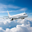

In [ ]:
# 사이즈 변환 (32,32)
airplane = airplane.resize((32,32))
airplane

array([[[ 53, 125, 184],
        [ 51, 123, 182],
        [ 44, 120, 180],
        ...,
        [  0,  70, 135],
        [  0,  69, 134],
        [  0,  69, 133]],

       [[ 52, 126, 186],
        [ 48, 124, 183],
        [ 46, 122, 182],
        ...,
        [  0,  73, 138],
        [  1,  71, 136],
        [  0,  70, 134]],

       [[ 64, 133, 191],
        [ 56, 129, 187],
        [ 51, 126, 186],
        ...,
        [  0,  75, 140],
        [  1,  74, 139],
        [  0,  73, 138]],

       ...,

       [[205, 212, 224],
        [198, 207, 221],
        [184, 197, 214],
        ...,
        [161, 170, 187],
        [167, 174, 189],
        [175, 178, 191]],

       [[147, 171, 197],
        [137, 164, 194],
        [160, 179, 202],
        ...,
        [142, 156, 180],
        [142, 156, 179],
        [155, 164, 182]],

       [[137, 163, 191],
        [128, 157, 188],
        [135, 161, 191],
        ...,
        [137, 151, 175],
        [145, 155, 177],
        [162, 167, 182]]], dtype=uint8)
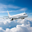

In [ ]:
# numpy 배열로 전환
import numpy as np

airplane = np.array(airplane)
airplane

In [ ]:
# 형태 변환
airplane = airplane.reshape(1, 32, 32, 3)
airplane

array([[[[ 53, 125, 184],
         [ 51, 123, 182],
         [ 44, 120, 180],
         ...,
         [  0,  70, 135],
         [  0,  69, 134],
         [  0,  69, 133]],

        [[ 52, 126, 186],
         [ 48, 124, 183],
         [ 46, 122, 182],
         ...,
         [  0,  73, 138],
         [  1,  71, 136],
         [  0,  70, 134]],

        [[ 64, 133, 191],
         [ 56, 129, 187],
         [ 51, 126, 186],
         ...,
         [  0,  75, 140],
         [  1,  74, 139],
         [  0,  73, 138]],

        ...,

        [[205, 212, 224],
         [198, 207, 221],
         [184, 197, 214],
         ...,
         [161, 170, 187],
         [167, 174, 189],
         [175, 178, 191]],

        [[147, 171, 197],
         [137, 164, 194],
         [160, 179, 202],
         ...,
         [142, 156, 180],
         [142, 156, 179],
         [155, 164, 182]],

        [[137, 163, 191],
         [128, 157, 188],
         [135, 161, 191],
         ...,
         [137, 151, 175],
        

In [ ]:
airplane.shape

(1, 32, 32, 3)

In [ ]:
# 정규화
airplane = airplane/255
airplane

array([[[[0.20784314, 0.49019608, 0.72156863],
         [0.2       , 0.48235294, 0.71372549],
         [0.17254902, 0.47058824, 0.70588235],
         ...,
         [0.        , 0.2745098 , 0.52941176],
         [0.        , 0.27058824, 0.5254902 ],
         [0.        , 0.27058824, 0.52156863]],

        [[0.20392157, 0.49411765, 0.72941176],
         [0.18823529, 0.48627451, 0.71764706],
         [0.18039216, 0.47843137, 0.71372549],
         ...,
         [0.        , 0.28627451, 0.54117647],
         [0.00392157, 0.27843137, 0.53333333],
         [0.        , 0.2745098 , 0.5254902 ]],

        [[0.25098039, 0.52156863, 0.74901961],
         [0.21960784, 0.50588235, 0.73333333],
         [0.2       , 0.49411765, 0.72941176],
         ...,
         [0.        , 0.29411765, 0.54901961],
         [0.00392157, 0.29019608, 0.54509804],
         [0.        , 0.28627451, 0.54117647]],

        ...,

        [[0.80392157, 0.83137255, 0.87843137],
         [0.77647059, 0.81176471, 0.86666667]

In [ ]:
# 라벨이름 가져오기
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

In [ ]:
class_names[9]

'truck'

In [ ]:
# 예측한 값을 라벨이름으로 변환
class_names[np.argmax(model.predict(airplane))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[9.9998808e-01, 2.2020792e-14, 7.7697822e-09, 2.8021362e-18,
        1.3385398e-12, 6.1458847e-25, 1.0210802e-17, 7.7294804e-26,
        1.1939612e-05, 1.1167705e-18]], dtype=float32)

# Cats and Dogs 예제

In [ ]:
!pip install Kaggle

In [ ]:
# 캐글에서 cats_and_dogs 파일 다운로드 받고 압축풀기
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
cat-and-dog.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# 압축 풀어서 저장
!unzip cat-and-dog.zip -d /content/cats_and_dogs

Streaming output truncated to the last 5000 lines.
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.3704.jpg  
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.3705.jpg  
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.3706.jpg  
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.3707.jpg  
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.3708.jpg  
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.3709.jpg  
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.371.jpg  
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.3710.jpg  
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.3711.jpg  
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.3712.jpg  
  inflating: /content/cats_and_dogs/training_set/training_set/cats/cat.3713.jpg  
  inflating: /content/cats_and_dogs/training_set

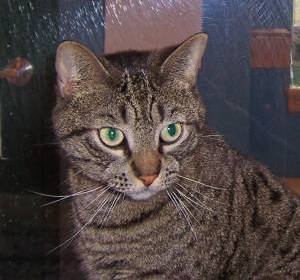

In [ ]:
# 고양이 훈련 데이터 열기
from PIL import Image

Image.open('/content/cats_and_dogs/training_set/training_set/cats/cat.1.jpg')

In [ ]:
# 폴더 안에 있는 파일 갯수 확인
import os

len(os.listdir('/content/cats_and_dogs/training_set/training_set/cats'))

4001

In [ ]:
len(os.listdir('/content/cats_and_dogs/training_set/training_set/dogs'))

4006

In [ ]:
len(os.listdir('/content/cats_and_dogs/test_set/test_set/cats'))

1012

In [ ]:
len(os.listdir('/content/cats_and_dogs/test_set/test_set/dogs'))

1013

In [ ]:
# 폴더 이름 저장
training_cat = '/content/cats_and_dogs/training_set/training_set/cats/'
training_dog = '/content/cats_and_dogs/training_set/training_set/dogs/'
test_cat = '/content/cats_and_dogs/test_set/test_set/cats/'
test_dog = '/content/cats_and_dogs/test_set/test_set/dogs/'

In [ ]:
# 파일 패쓰 + 이름 출력
for i in range(9):
    print(training_cat + os.listdir('/content/cats_and_dogs/training_set/training_set/cats')[i])

/content/cats_and_dogs/training_set/training_set/cats/cat.3703.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.3739.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.2853.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.2206.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.3496.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.1983.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.3265.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.1355.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.1148.jpg


In [ ]:
# 파일 패쓰 + 이름 출력 (os.path.join 이용)
for i in range(9):
    print(os.path.join(training_cat, os.listdir('/content/cats_and_dogs/training_set/training_set/cats')[i]))

/content/cats_and_dogs/training_set/training_set/cats/cat.3703.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.3739.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.2853.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.2206.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.3496.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.1983.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.3265.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.1355.jpg
/content/cats_and_dogs/training_set/training_set/cats/cat.1148.jpg


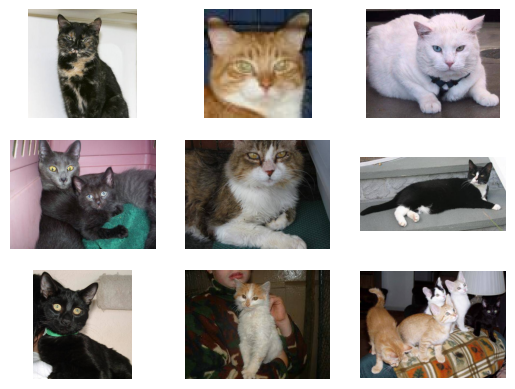

In [ ]:
import matplotlib.pyplot as plt

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(Image.open(os.path.join(training_cat, os.listdir('/content/cats_and_dogs/training_set/training_set/cats')[i])))
    plt.axis('off')

# 이미지 데이터 증강

In [ ]:
# 폴더에 있는 이미지 데이터 증강 생성 (150x150)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale = 1.0/255., # 픽셀값 스케일 범위 [0,1]
    rotation_range=40, # 40 도까지 임의 회전
    width_shift_range=0.2, # 수평이동
    height_shift_range=0.2, # 수직이동
    shear_range=0.2, # 전단변환
    zoom_range=0.2, # 20%까지 임의 확대
    horizontal_flip=True) #수평플립

train_dir = "/content/cats_and_dogs/training_set/training_set"

train = train_datagen.flow_from_directory(
    train_dir, #훈련이미지가 있는 폴더
    target_size=(150,150), #이미지 사이즈 변경
    class_mode='binary' #이진 레이블
)

test_datagen = ImageDataGenerator()

validataion_dir = "/content/cats_and_dogs/test_set/test_set"

test = test_datagen.flow_from_directory(
    validataion_dir, #검증이미지가 있는 폴더
    target_size=(150,150), #이미지 사이즈 변경
    class_mode='binary' #이진 레이블
)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [ ]:
# 모델생성
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

model = Sequential()
model.add(Conv2D(32, 3, activation='relu', input_shape=(150,150,3)))
model.add(MaxPool2D(2,2))
model.add(Conv2D(64, 3, activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Conv2D(128, 3, activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Conv2D(128, 3, activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Flatten())
model.add(Dropout(.5))
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# 체크 포인트, 조기 종료 설정
from keras.callbacks import ModelCheckpoint, EarlyStopping

save_file_name = 'cats_and_dogs.h5'
checkpoint = ModelCheckpoint(save_file_name, monitor='val_accuracy',
                             verbose=1, save_best_only=True, mode='auto')
earlystopping = EarlyStopping(monitor='val_accuracy', patience=5)

In [ ]:
# 모델 학습
history = model.fit(train, epochs=100, batch_size=64, validation_data=test, verbose=1, callbacks=[checkpoint, earlystopping])

Epoch 1/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5116 - loss: 0.6969
Epoch 1: val_accuracy improved from None to 0.50618, saving model to cats_and_dogs.h5



Epoch 1: finished saving model to cats_and_dogs.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 496s 2s/step - accuracy: 0.5323 - loss: 0.6893 - val_accuracy: 0.5062 - val_loss: 6.9895
Epoch 2/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5689 - loss: 0.6801
Epoch 2: val_accuracy improved from 0.50618 to 0.54128, saving model to cats_and_dogs.h5



Epoch 2: finished saving model to cats_and_dogs.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.5784 - loss: 0.6745 - val_accuracy: 0.5413 - val_loss: 80.8652
Epoch 3/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6067 - loss: 0.6547
Epoch 3: val_accuracy did not improve from 0.54128
251/251 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.6190 - loss: 0.6502 - val_accuracy: 0.5012 - val_loss: 139.8770
Epoch 4/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6427 - loss: 0.6366
Epoch 4: val_accuracy improved from 0.54128 to 0.54968, saving model to cats_and_dogs.h5



Epoch 4: finished saving model to cats_and_dogs.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - accuracy: 0.6376 - loss: 0.6377 - val_accuracy: 0.5497 - val_loss: 74.5349
Epoch 5/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6608 - loss: 0.6281
Epoch 5: val_accuracy improved from 0.54968 to 0.56747, saving model to cats_and_dogs.h5



Epoch 5: finished saving model to cats_and_dogs.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step - accuracy: 0.6688 - loss: 0.6148 - val_accuracy: 0.5675 - val_loss: 72.4870
Epoch 6/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6905 - loss: 0.5824
Epoch 6: val_accuracy improved from 0.56747 to 0.63075, saving model to cats_and_dogs.h5



Epoch 6: finished saving model to cats_and_dogs.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.6941 - loss: 0.5828 - val_accuracy: 0.6307 - val_loss: 33.9965
Epoch 7/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7138 - loss: 0.5615
Epoch 7: val_accuracy did not improve from 0.63075
251/251 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.7132 - loss: 0.5638 - val_accuracy: 0.5848 - val_loss: 89.6085
Epoch 8/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7222 - loss: 0.5526
Epoch 8: val_accuracy improved from 0.63075 to 0.63816, saving model to cats_and_dogs.h5



Epoch 8: finished saving model to cats_and_dogs.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.7264 - loss: 0.5496 - val_accuracy: 0.6382 - val_loss: 75.4695
Epoch 9/100
 25/251 ━━━━━━━━━━━━━━━━━━━━ 6:40 2s/step - accuracy: 0.7262 - loss: 0.5386

In [ ]:
# accuracy 히스토리 그래프
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
# loss 히스토리 그래프
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
# 테스트 이미지 분류
from PIL import Image

dog = Image.open('/content/chihuahua.jpg')

In [ ]:
# 전처리
dog = dog.resize((150,150))
dog = np.array(dog)
dog = dog.reshape(1,150,150,3)
dog = dog/255

In [ ]:
model.predict(dog)

# 전이학습


In [ ]:
# 필요한 라이브러리 import
import keras
from keras.applications.resnet50 import ResNet50  # ResNet50 모델
from keras.applications.resnet50 import preprocess_input, decode_predictions  # 전처리 및 예측 결과 디코딩
import numpy as np # 수치 계산용 라이브러리

# ImageNet 데이터셋으로 사전 학습된 ResNet50 모델 불러오기
model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
# 예측에 사용할 이미지 파일 경로 지정
img_path = '/content/chihuahua.jpg'

# 이미지를 불러오고 ResNet50 입력 크기인 (224, 224)로 리사이즈
img = keras.utils.load_img(img_path, target_size=(224, 224))

# 이미지를 NumPy 배열로 변환
x = keras.utils.img_to_array(img)

# 배열의 차원을 (1, 224, 224, 3)으로 확장 → 배치 크기 포함
x = np.expand_dims(x, axis=0)

# ResNet50에 맞는 전처리 수행 (픽셀 정규화 등)
x = preprocess_input(x)

In [ ]:
# 모델에 입력 데이터를 넣고 예측 수행
preds = model.predict(x)
preds

In [ ]:
print('Predicted:', decode_predictions(preds, top=3)[0])

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted: [('n02085620', 'Chihuahua', np.float32(0.7145298)), ('n02112018', 'Pomeranian', np.float32(0.2517786)), ('n02086079', 'Pekinese', np.float32(0.012230105))]


In [ ]:
print('Predicted:', decode_predictions(preds)[0])

Predicted: [('n02085620', 'Chihuahua', np.float32(0.7145298)), ('n02112018', 'Pomeranian', np.float32(0.2517786)), ('n02086079', 'Pekinese', np.float32(0.012230105)), ('n03803284', 'muzzle', np.float32(0.010196761)), ('n02086910', 'papillon', np.float32(0.0055386457))]
